## More on the Generalization bound

We have seen previously that it is possible to bound $E_{out}$ using as a proxy $E_{in} + \epsilon$ where  we have 

$$  \epsilon  = \sqrt{ \frac{8}{N} ln \frac{4mH(2N)}{\delta}}$$

$$ E_{out}(g) \le E_{in}(g) + \sqrt{ \frac{8}{N} ln \frac{4mH(2N)}{\delta}} $$

This result is theoretically sound, and indeed is the edifice upon which the feasibility of learning rests, however it is a very loose bound. There are a couple of important points to make regarding the bound though.  One is that it is usually *equally* loose for different models, and so provides a good relative estimation of generalization performance. 

The second point is that we can use it to give us a way to calculate a sufficient $N$ required to achieve good generalization performance for a particular model. 

Thus we have 


$$ N \ge   \frac{8}{ \epsilon ^ 2} ln \frac{4mH(2N)}{\delta} $$

This means we need to find a value for N that makes the above statement true. Using an iterative process where we make an initial guess, and then repeatedly feed N back into the right hand side above, we can converge on a value for N


In [1]:
import analysis_tools as at 

N=1000
print "initial N: " + str(N)

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N

N = at.determine_n(N=N, tolerance=.1, d_vc=6, error=.1)
print N


initial N: 1000
39435.4353691
57073.8263465
58848.2943876
58995.2570535
59007.2292175
59008.2032035
59008.2824327
59008.2888776
59008.2894018
59008.2894445
59008.289448


So it becomes clear that we converge at a value for N around 59,000. We can interpret this as saying that in order to get good generalization for our example room occupancy data set, where d_vc was 6, specifically error of 10%, plus or minus 10% out of sample, we need to use an N of at least 59,000 samples. 

## Test

The information we have gained is important, but remember that we also have another way to gather information about how our algorithm can be expected to generalize, and that is to try out our trained weight vector on samples that were not used in training, but which were generated by the same process. 

In [2]:
import pocket as pk

# setup our training data
training = at.load_data(file_name='datatraining.txt', y_name='Occupancy')

# setup our testing data
testing = at.load_data(file_name='datatest.txt', y_name='Occupancy')

fit = pk.pocket(training, iterations=30)
w = fit['w']

e_in = at.misclassified_count(w=w, data=training)
e_test = at.misclassified_count(w=w, data=testing)


at.print_results(e_in=e_in, e_test=e_test)



E_in number misclassified: 558, percentage error: 0.0685251135945
E_test number misclassified: 184, percentage error: 0.06904315197




As we saw before, the VC generalization bound appears to be pretty poor in terms of what we can expect with regard to performance on $E_{out}$.  Can we do better than this bound if we have a test set?  It turns out that we can.....as we are only testing our best hypothesis $g$, which is represented by our best weight vector $w$, on a single data set, and we are not varying our hypothesis.  This situtation may sound familiar, it is the situation where the Hoeffding inequality applies, namely where we start with a hypothesis $g$, that does not change, and we use it to classify $X$, which in this case is the dataset our alogrithm has not seen yet. 

This will allow us to use a much tighter bound, using the Hoeffding Inequality which will apply to a single hypothesis: 

$$ E_{out} \le E_{test} + \sqrt{ \frac{1}{2N} ln \frac{2M}{\delta} } $$

In [2]:
hoeffding_bound = at.hoeffding_bound(N=1000,tolerance=.07)
vc_bound  = at.vc_bound(N=100,tolerance=.07,d_vc=6)

at.print_results(vc=vc_bound, hoeffding=hoeffding_bound)



VC bound: 1.69388036995
Hoeffding bound: 0.0409414656399




The above comparison of the *hoeffding_bound* vs. the *vc_bound* should really crystallize the penalty for model complexity that the *vc_bound* encapsulates. This is a very powerful line of analysis that leads to insights about the fundamental tradeoffs between model complexity and generalization error.  

## Our expected generalization error

Based on our tighter formulation of the generalization bound based on the hoeffding inequality and our test data set, we can restate our expected error. Remember to think of this as in comparison against the *worst case bound* which the VC gives us. 

$$ E_{out} \le 0.069 + .040 $$

$$ E_{out} \le .109 $$

This means we can say with $93\%$ confidence $E_{out}$ will be no worse than $ \approx11\%$.  This is a much more reasonable bound, and it is an *empirical* bound in the sense that we test our hypothesis on data not used during training.  It is important to bear in mind one important concern, and that is the training data, and the data the alogrithm will see 'in the wild', are assumed to be generated by the same process. In other words, the true *f(x)*, which must remain unknown, is assumed to remain unknown, but also remain *stationary*. 

## Some further generalization bounds

The VC bound was the first generalization result that established the feasiblitiy of learning, however other have been derived as well. Here we will look at a few others, based on problem **2.20** in the book. 


> Rademacher Penalty Bound

$$ \epsilon \le \sqrt{ \frac{2ln(2Nm_{h}(N))}{N} } + \sqrt{ \frac{2}{N} ln \frac{1}{\delta} } + \frac{1}{N}  $$

> Parrondo and Van den Broek

$$ \epsilon \le \sqrt{ \frac{1}{N} \left( 2\epsilon + ln \frac{6m_h(2N)}{\delta}  \right) }  $$

> Devroye

$$ \epsilon \le \sqrt{ \frac{1}{2N} \left( 4\epsilon(1 + \epsilon) + ln \frac{4m_h(N^2)}{\delta} \right) } $$

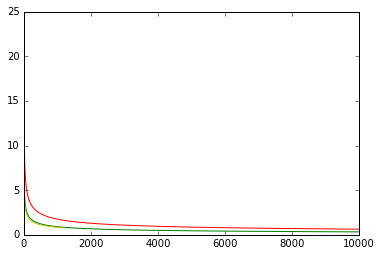

In [2]:
%matplotlib inline

at.compare_generalization_bounds(range_n=range(1,10000), d_vc=50, tolerance=.1, epsilon=.1)